# Exodus sets/steps and spatial pipeline v2

A synthetic two-tetrahedron solve writes fixed node/side sets and three temperature states into one Exodus file. A Version 2 pipeline merges that final state with a translated copy and partitions it into two files. No downloaded fixtures are needed; netCDF support (native or the Python netCDF4 fallback) is required.

In [1]:
import os
import tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import meshioplusplus as mp

os.environ['PYVISTA_OFF_SCREEN'] = 'true'
workspace = tempfile.TemporaryDirectory()
root = Path(workspace.name)
points = np.array([[0., 0., 0.], [1., 0., 0.], [0., 1., 0.],
                   [0., 0., 1.], [1., 1., 1.]])
mesh = mp.Mesh(points, [('tetra', np.array([[0, 1, 2, 3], [1, 2, 3, 4]]))],
    point_data={'temperature': np.linspace(0., 1., 5)},
    cell_data={'exodus:attr:material': [np.array([1., 2.])]},
    regions=[mp.Region('anchors', 'point', [0, 2], tag=41),
             mp.Region('wall', 'side', [[0, 0], [1, 1]], tag=91)])
series_path = root / 'solve.e'
with mp.exodus.TimeSeriesWriter(series_path) as writer:
    writer.write_points_cells(mesh)
    for time in [0., 0.5, 1.]:
        state = mesh.copy()
        state.point_data['temperature'] += time
        writer.write_data(time, state)
    writer.flush()
    print('Completed Exodus steps:', writer.num_steps)
last = mp.read(series_path, time_step=-1)
print('Recorded times:', mp.read_metadata(series_path)['time_values'])
print('Fixed sets:', [(r.name, r.tag) for r in last.regions if r.kind != 'cell'])


Completed Exodus steps: 3
Recorded times: [0.0, 0.5, 1.0]
Fixed sets: [('anchors', 41), ('wall', 91)]


## Ordered merge, then terminal fan-out

The current mesh is Merge's first input. Inputs lists additional paths in order. Partition is terminal when Output.Pattern contains {part}; the generated files carry original-id maps. Input.Options.TimeStep explicitly selects the last Exodus state, keeping this a spatial document rather than a transient pipeline.

In [2]:
shifted = mp.transform(last, translate=[2., 0., 0.])
mp.write(root / 'shifted.vtu', shifted, compression=None)
settings = {
    'Version': 2,
    'Input': {'Path': str(series_path), 'Options': {'TimeStep': -1}},
    'Operations': [
        {'Op': 'Merge', 'Inputs': [str(root / 'shifted.vtu')]},
        {'Op': 'Partition', 'Nparts': 2, 'Method': 'sfc', 'RecordIds': True}],
    'Output': {'Pattern': str(root / 'part_{part}.vtu'), 'Codec': 'none'}}
print(mp.run_pipeline(settings))
pieces = [mp.read(root / f'part_{part}.vtu') for part in range(2)]
print('Piece cell counts:', [sum(len(c) for c in piece.cells) for piece in pieces])


{'steps': [{'op': 'Merge', 'NumInputs': 2.0}, {'op': 'Partition', 'NumPieces': 2.0}], 'warnings': []}
Piece cell counts: [2, 2]


meshio warning [region_remap.cpp:526] partition: side region '1:wall' lost 2 of its 2 facet(s) — they have no counterpart in the output
meshio warning [region_remap.cpp:526] partition: side region '0:wall' lost 2 of its 2 facet(s) — they have no counterpart in the output


meshio warning [region_remap.cpp:605] extract_surface: cell region 'Block 0' dropped — it names input cells, and the output holds only their facets


meshio warning [region_remap.cpp:605] extract_surface: cell region '0:Block 0' dropped — it names input cells, and the output holds only their facets
meshio warning [region_remap.cpp:605] extract_surface: cell region '1:Block 0' dropped — it names input cells, and the output holds only their facets
meshio warning [region_remap.cpp:605] extract_surface: cell region '0:Block 0' dropped — it names input cells, and the output holds only their facets
meshio warning [region_remap.cpp:605] extract_surface: cell region '1:Block 0' dropped — it names input cells, and the output holds only their facets


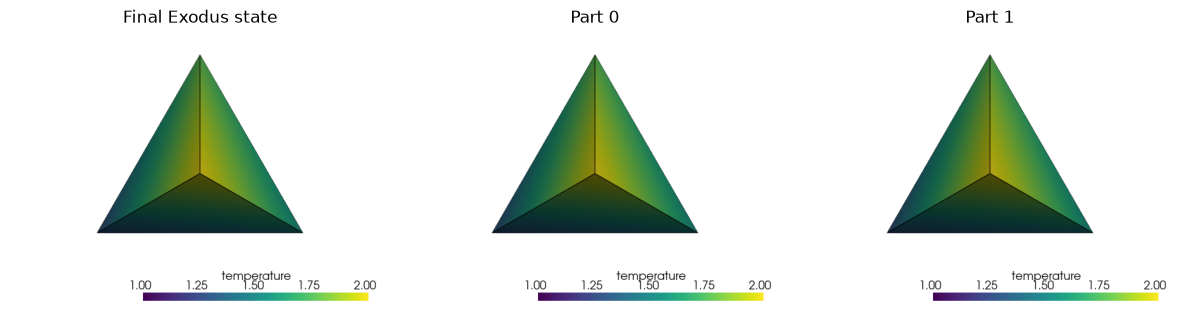

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, current, title in zip(axes, [last] + pieces, ['Final Exodus state', 'Part 0', 'Part 1']):
    plotter = None
    try:
        import pyvista as pv
        grid = mp.to_pyvista(mp.extract_surface(current))
        plotter = pv.Plotter(off_screen=True, window_size=(600, 450))
        plotter.set_background('white')
        plotter.add_mesh(grid, scalars='temperature', cmap='viridis', show_edges=True, clim=[1, 2])
        plotter.camera_position = 'iso'
        image = plotter.screenshot(return_img=True)
        ax.imshow(image)
        ax.axis('off')
    except Exception:
        surface = mp.extract_surface(current)
        for block in surface.cells:
            for row in block.data:
                loop = np.r_[row, row[0]]
                ax.plot(surface.points[loop, 0], surface.points[loop, 1], color='0.5', alpha=0.5)
        ax.scatter(current.points[:, 0], current.points[:, 1], c=current.point_data['temperature'],
                   cmap='viridis', vmin=1, vmax=2, s=80, edgecolor='black')
        ax.set_aspect('equal')
    finally:
        if plotter is not None:
            plotter.close()
    ax.set_title(title)
fig.tight_layout()
plt.show()
